In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

In [2]:
df = pd.read_csv('Downloads/dataset (1).csv')

In [3]:
# Sort by time
df = df.sort_values(by='Date Main')

# Target
data = df['garch_volatility'].values.reshape(-1, 1)

# Scale (VERY IMPORTANT for LSTM)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [4]:
def create_sequences(data, window_size=10):
    X, Y = [], []
    
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        Y.append(data[i])
    
    return np.array(X), np.array(Y)

window_size = 10
X, Y = create_sequences(data_scaled, window_size)

In [5]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

In [6]:
model = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

In [7]:
model.fit(X_train, Y_train, epochs=20, batch_size=16, verbose=1)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0242
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0230
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0229
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0225 
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0221 
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0218 
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0213 
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0207 
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0207 
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0201 
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0200 
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0199 
Epoch 13/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0196 
Epoch 14/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0197 
Epoch 15/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0196 
Epoch 1

In [8]:
preds = model.predict(X_test)

# Inverse scaling
preds = scaler.inverse_transform(preds)
Y_test_actual = scaler.inverse_transform(Y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step


In [17]:
r2_vol = r2_score(Y_test_actual, preds)
rmse_vol = np.sqrt(mean_squared_error(Y_test_actual, preds))
mae_vol = mean_absolute_error(Y_test_actual, preds)

print("R2:", r2_vol)
print("RMSE:", rmse_vol)
print("MAE:", mae_vol)

R2: -213.41576509708446
RMSE: 2.9351828146478924
MAE: 2.9032852484516307


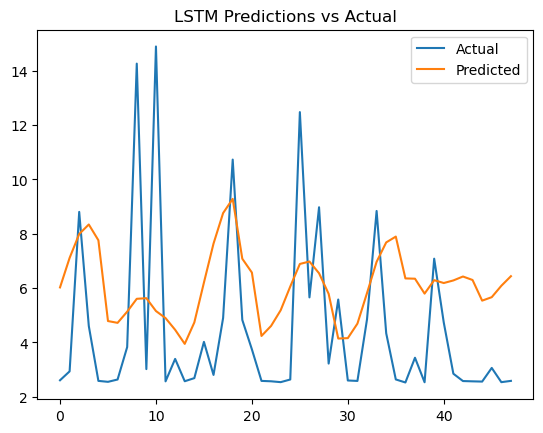

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(Y_test_actual, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title("LSTM Predictions vs Actual")
plt.show()

In [11]:
df = df.sort_values(by='Date Main')

data = df['garch_volatility'].values.reshape(-1, 1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [12]:
def create_sequences(data, window_size=10):
    X, Y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        Y.append(data[i])
    return np.array(X), np.array(Y)

In [13]:
n = len(data_scaled)

splits = [
    int(0.80 * n),
    int(0.90 * n),
    int(0.95 * n),
    int(0.98 * n)
]

In [16]:
window_size = 10
results = []

for i, split in enumerate(splits):

    train_data = data_scaled[:split]
    test_data = data_scaled[split-window_size:]  # include window overlap

    X_train, Y_train = create_sequences(train_data, window_size)
    X_test, Y_test = create_sequences(test_data, window_size)

    model = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(50),
    Dense(1)
      ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train, Y_train, epochs=15, batch_size=16, verbose=0)

    preds = model.predict(X_test)

    # Inverse scaling
    preds = scaler.inverse_transform(preds)
    Y_test_actual = scaler.inverse_transform(Y_test)

    # Metrics
    mse = mean_squared_error(Y_test_actual, preds)
    mae = mean_absolute_error(Y_test_actual, preds)
    r2 = r2_score(Y_test_actual, preds)

    # Directional Accuracy
    actual_diff = Y_test_actual[1:] - Y_test_actual[:-1]
    pred_diff = preds[1:] - Y_test_actual[:-1]

    direction = np.sign(actual_diff) == np.sign(pred_diff)
    da = np.mean(direction)

    results.append({
        "Split": i+1,
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Directional Accuracy": da
    })

    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {da:.4f}
    """)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step

    Split 1
    Train Size: 200
    Test Size: 50
    MSE: 11.1812
    MAE: 2.8812
    R2: -0.1757
    Directional Accuracy: 0.6327
    
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step

    Split 2
    Train Size: 225
    Test Size: 25
    MSE: 9.1538
    MAE: 2.7974
    R2: -0.4082
    Directional Accuracy: 0.6250
    
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step

    Split 3
    Train Size: 237
    Test Size: 13
    MSE: 8.0624
    MAE: 2.6854
    R2: -4.0211
    Directional Accuracy: 0.4167
    
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step

    Split 4
    Train Size: 245
    Test Size: 5
    MSE: 8.6153
    MAE: 2.9033
    R2: -213.4158
    Directional Accuracy: 0.5000
    


In [15]:
results_df = pd.DataFrame(results)

print(results_df)

   Split        MSE       MAE          R2  Directional Accuracy
0      1  12.765790  3.145532   -0.342358              0.632653
1      2   8.236707  2.597927   -0.267153              0.625000
2      3   9.444021  2.922384   -4.881536              0.416667
3      4   9.627247  3.071488 -238.600940              0.500000
